<a href="https://colab.research.google.com/github/prajwalbhandari416/Time-Dependent-Wave-Equations/blob/main/Time_Dependent_solver_examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qmsolve

  Preparing metadata (setup.py) ... done
  Created wheel for progressbar: filename=progressbar-2.5-py3-none-any.whl size=12065 sha256=5936f8ce85fcf0a1122fa39308e7507b096b6b3f746225d00521b8e872ba9f40
  Stored in directory: /root/.cache/pip/wheels/15/38/9d/0d335445b021c31266d906b07313cd961adc1e7cece18579e9
Successfully built progressbar


In [ ]:
import qmsolve

print(qmsolve.__file__)

/usr/local/lib/python3.13/dist-packages/qmsolve/__init__.py


In [ ]:
import numpy as np

from qmsolve import (
    Hamiltonian,
    SingleParticle,
    TimeSimulation,
    init_visualization,
    femtoseconds,
    m_e,
    Å,
    eV
)

In [ ]:
# 1D Harmonic Oscillator

import numpy as np

from qmsolve import (
    Hamiltonian,
    SingleParticle,
    TimeSimulation,
    init_visualization,
    femtoseconds,
    m_e,
    Å,
    eV
)

# --------------------------------------------------
# Define the interaction potential
# --------------------------------------------------

def harmonic_oscillator(particle):

    k = 100.0 * eV / Å**2

    return 0.5 * k * particle.x**2


# --------------------------------------------------
# Define the Hamiltonian
# --------------------------------------------------

H = Hamiltonian(
    particles=SingleParticle(m=m_e),
    potential=harmonic_oscillator,
    spatial_ndim=1,
    N=512,
    extent=20 * Å
)

In [ ]:
eigenstates = H.solve(max_states=10)

print("Energy eigenvalues:")
print(eigenstates.energies)

Computing...
Took 0.0459897518157959
Energy eigenvalues:
[ 13.8243627   41.46350403  69.08346722  96.68423227 124.26577906
 151.82808744 179.37113718 206.89490796 234.39937942 261.8845311 ]


In [ ]:
!pip show qmsolve

Name: qmsolve
Version: 2.0.0
Summary: A module for solving and visualizing the Schrödinger equation
Home-page: https://github.com/quantum-visualizations/qmsolve
Author: Rafael de la Fuente, marl0ny, Hudson Smith
Author-email: rafael.fuente.herrezuelo@gmail.com, lammarlonaurel123456789@gmail.com, dhudsmith@gmail.com
License: BSD-3-Clause
Location: /usr/local/lib/python3.13/dist-packages
Requires: h5py, matplotlib, numpy, progressbar, scipy
Required-by: 


In [ ]:
import sys
print(sys.executable)

/usr/bin/python3


Took 0.32921504974365234


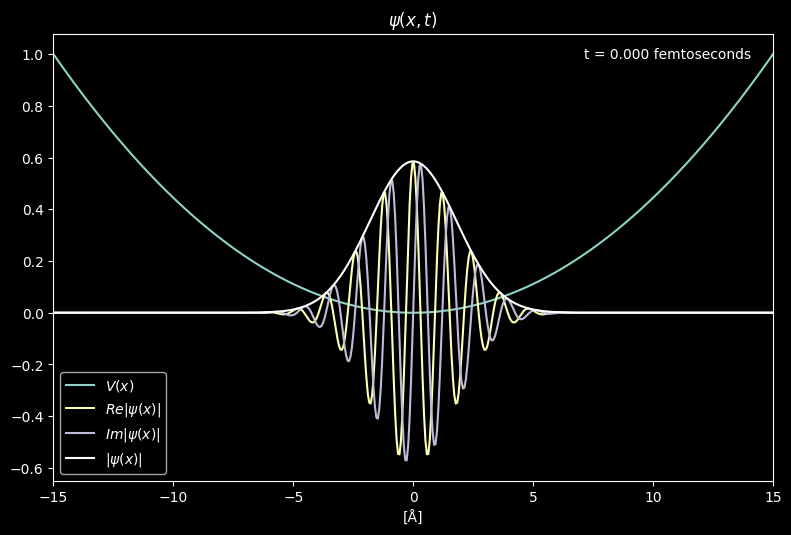

In [ ]:
#1D Harmonic Oscillator
import numpy as np
from qmsolve import Hamiltonian, SingleParticle, TimeSimulation, init_visualization, femtoseconds, m_e, Å

#=========================================================================================================#
# First, we define the Hamiltonian of a single particle confined in an harmonic oscillator potential.
#=========================================================================================================#

#interaction potential
def harmonic_oscillator(particle):
    m = m_e
    T = 0.6*femtoseconds
    w = 2*np.pi/T
    k = m* w**2
    return 0.5 * k * particle.x**2


#build the Hamiltonian of the system
H = Hamiltonian(particles = SingleParticle(m = m_e),
                potential = harmonic_oscillator,
                spatial_ndim = 1, N = 500, extent = 30 * Å)


#=========================================================================================================#
# Define the wavefunction at t = 0  (initial condition)
#=========================================================================================================#

def initial_wavefunction(particle):
    #This wavefunction correspond to a gaussian wavepacket with a mean X momentum equal to p_x0
    σ = 0.7 * Å
    v0 = 60 * Å / femtoseconds
    p_x0 = m_e * v0
    return np.exp( -1/(4* σ**2) * ((particle.x-0)**2) / np.sqrt(2*np.pi* σ**2))  *np.exp(p_x0*particle.x*1j)

#=========================================================================================================#
# Set and run the simulation
#=========================================================================================================#

total_time = 1.8 * femtoseconds
#set the time dependent simulation
sim = TimeSimulation(hamiltonian = H, method = "split-step")
sim.run(initial_wavefunction, total_time = total_time, dt = total_time/1600., store_steps = 800)

#=========================================================================================================#
# Finally, we visualize the time dependent simulation
#=========================================================================================================#

visualization = init_visualization(sim)
visualization.animate(xlim=[-15* Å,15* Å], animation_duration = 10, save_animation = False, fps = 30)


#for visualizing a single frame, use plot method instead of animate:
#visualization.plot(t = 5/4 * 0.9 * femtoseconds,xlim=[-15* Å,15* Å])

Took 36.68186402320862


/usr/local/lib/python3.13/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


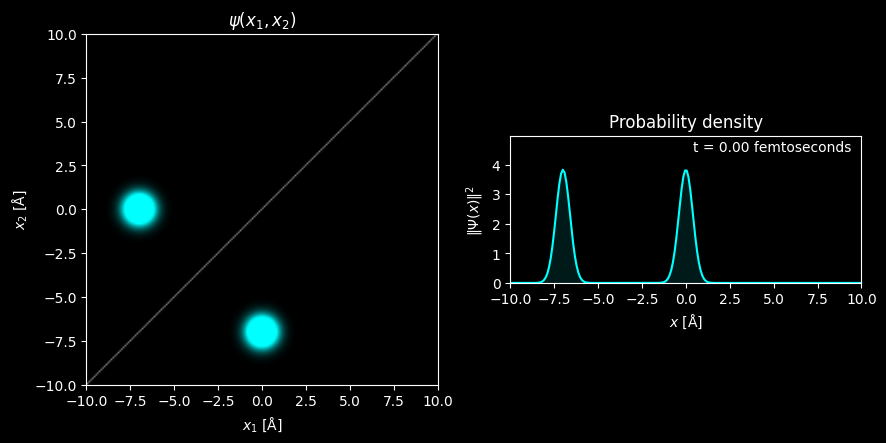

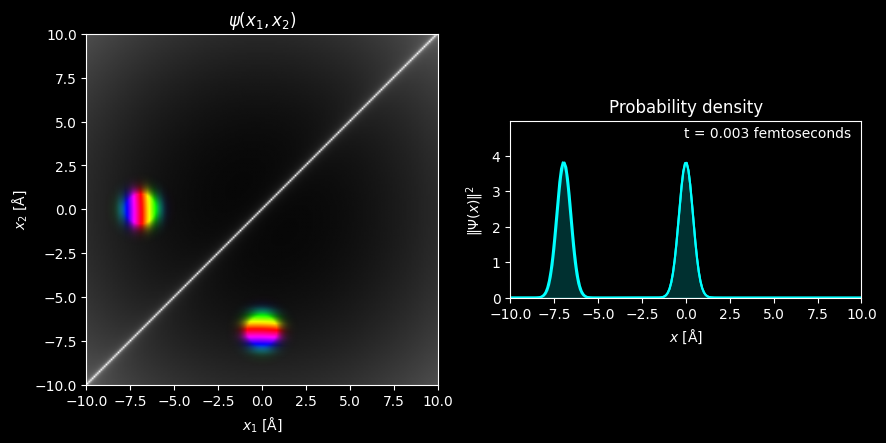

In [ ]:
import numpy as np
from qmsolve import Hamiltonian, TwoBosons, TimeSimulation, init_visualization,Å,m_e, femtoseconds


#interaction potential
def harmonic_oscillator_plus_coulomb_interaction(fermions):
	k = 0.5
	V_harmonic = 0.5*k*fermions.x1**2 + 0.5*k*fermions.x2**2

	k = 30.83
	r = np.abs(fermions.x1 - fermions.x2)
	r = np.where(r < 0.0001, 0.0001, r)
	V_coulomb_interaction = k/ r

	return V_harmonic + V_coulomb_interaction



#build the Hamiltonian of the system
H = Hamiltonian(particles = TwoBosons(),
				potential = harmonic_oscillator_plus_coulomb_interaction,
				spatial_ndim = 1, N = 256, extent = 25*Å)


def initial_wavefunction(particle):
    #This wavefunction correspond to two stationary gaussian wavepackets. The wavefunction must be symmetric: Ψ(x1,x2) = Ψ(x2,x1)
    σ = 0.4 * Å
    x1 = particle.x1
    x2 = particle.x2
    𝜇01 = -7.0*Å
    𝜇02 = 0.0*Å

    return (np.exp(-(x1 - 𝜇01)**2/(4*σ**2))*np.exp(-(x2 - 𝜇02)**2/(4*σ**2))
            + np.exp(-(x1 - 𝜇02)**2/(4*σ**2))*np.exp(-(x2 - 𝜇01)**2/(4*σ**2)))


total_time = 0.5 * femtoseconds
sim = TimeSimulation(hamiltonian = H, method = "split-step")
sim.run(initial_wavefunction, total_time = total_time, dt = total_time/8000., store_steps = 400)

visualization = init_visualization(sim)
visualization.plot(t = 0, xlim=[-10* Å,10* Å], potential_saturation = 0.5, wavefunction_saturation = 0.2)

visualization.animate(xlim=[-10* Å,10* Å], potential_saturation = 500, wavefunction_saturation = 0.2, animation_duration = 10, save_animation = False)

Took 17.60597538948059


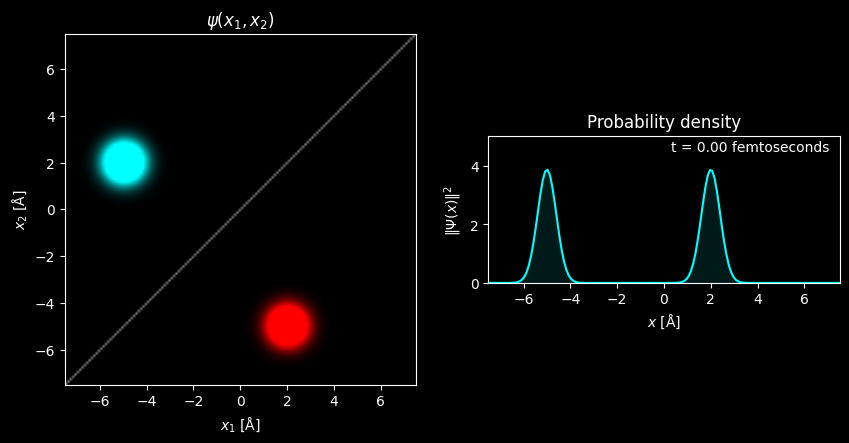

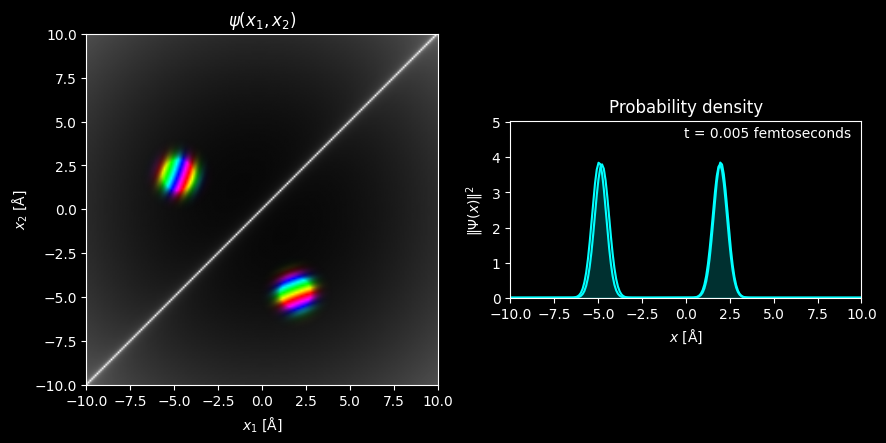

In [ ]:
#1D Interactive Fermions
import numpy as np
from qmsolve import Hamiltonian, TwoFermions, TimeSimulation, init_visualization,Å,m_e, femtoseconds


#interaction potential
def harmonic_oscillator_plus_coulomb_interaction(fermions):
	k = 0.5
	V_harmonic = 0.5*k*fermions.x1**2 + 0.5*k*fermions.x2**2

	k = 30.83
	r = np.abs(fermions.x1 - fermions.x2)
	r = np.where(r < 0.0001, 0.0001, r)
	V_coulomb_interaction = k/ r

	return V_harmonic + V_coulomb_interaction



#build the Hamiltonian of the system
H = Hamiltonian(particles = TwoFermions(),
				potential = harmonic_oscillator_plus_coulomb_interaction,
				spatial_ndim = 1, N = 200, extent = 20*Å)


def initial_wavefunction(particle):
    #This wavefunction correspond to two stationary gaussian wavepackets. The wavefunction must be antisymmetric: Ψ(x1,x2) = -Ψ(x2,x1)
    σ = 0.4 * Å
    x1 = particle.x1
    x2 = particle.x2
    𝜇01 = -5.0*Å
    𝜇02 = 2.0*Å

    return (np.exp(-(x1 - 𝜇01)**2/(4*σ**2))*np.exp(-(x2 - 𝜇02)**2/(4*σ**2))
            - np.exp(-(x1 - 𝜇02)**2/(4*σ**2))*np.exp(-(x2 - 𝜇01)**2/(4*σ**2)))


total_time = 1. * femtoseconds
sim = TimeSimulation(hamiltonian = H, method = "split-step")
sim.run(initial_wavefunction, total_time = total_time, dt = total_time/8000., store_steps = 400)

visualization = init_visualization(sim)
visualization.plot(t = 0, xlim=[-7.5* Å,7.5* Å], potential_saturation = 0.5, wavefunction_saturation = 0.2)

visualization.animate(xlim=[-10* Å,10* Å], potential_saturation = 500, wavefunction_saturation = 0.2, animation_duration = 10, save_animation = False)

Took 1.1418719291687012


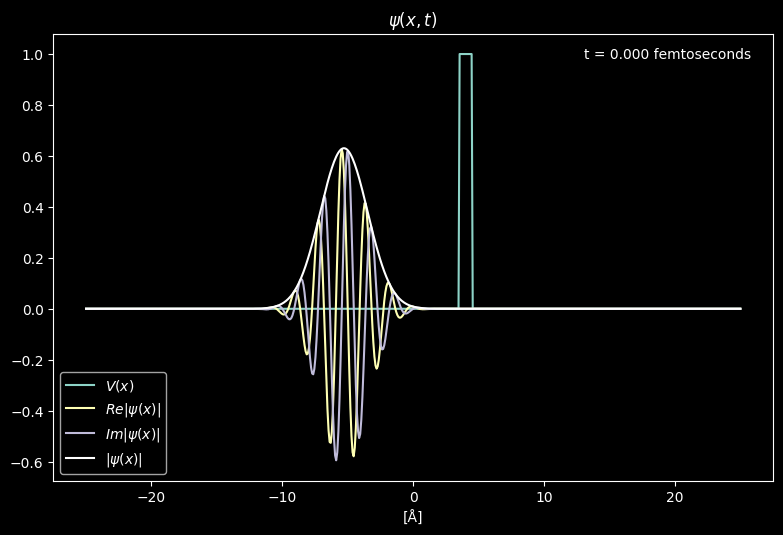

In [ ]:
#1D Potential Barrier
import numpy as np
from qmsolve import Hamiltonian, SingleParticle, TimeSimulation, init_visualization, femtoseconds, m_e, Å


#interaction potential
def potential_barrier(particle):
    #This wavefunction correspond to a gaussian wavepacket with a mean X momentum equal to p_x0
    V0 = 2
    a = 1  * Å
    x0 = 4  * Å
    barrier = np.where((particle.x > x0 - a/2) & (particle.x < x0 + a/2), V0, 0)
    return barrier


#build the Hamiltonian of the system
H = Hamiltonian(particles = SingleParticle(m = m_e),
                potential = potential_barrier,
                spatial_ndim = 1, N = 600, extent = 50 * Å)


#wavefunction at t = 0.
def initial_wavefunction(particle):
    #This wavefunction correspond to a gaussian wavepacket with a mean X momentum equal to p_x0
    σ = 0.7 * Å
    v0 = 40 * Å / femtoseconds
    p_x0 = m_e * v0
    return np.exp( -1/(4* σ**2) * ((particle.x+10)**2) / np.sqrt(2*np.pi* σ**2))  *np.exp(p_x0*particle.x*1j)


total_time = 0.5 * femtoseconds

#set the time dependent simulation
sim = TimeSimulation(hamiltonian = H, method = "split-step")
sim.run(initial_wavefunction, total_time = total_time, dt = total_time/5000., store_steps = 800)

#visualize the time dependent simulation
visualization = init_visualization(sim)
visualization.animate(animation_duration = 10, fps = 30)


#for visualizing a single frame, use plot method instead of animate:
#visualization.plot(t = 5/4 * 0.9 * femtoseconds,xlim=[-15* Å,15* Å])

classical cyclotron radius = 4.55 angstroms
classical cyclotron period = 0.36 femtoseconds


Took 113.23036885261536


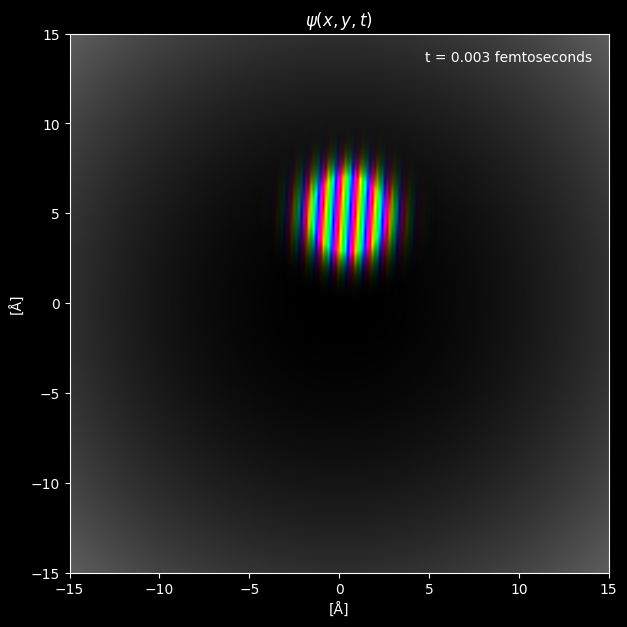

In [ ]:
#2D Cyclotron Orbit Magnetic field
import numpy as np
from qmsolve import Hamiltonian, SingleParticle,TimeSimulation, init_visualization, m_e, e, Å, T , eV, femtoseconds

#==========================================================================================================================================================================
# This example simulated the time evolution of a charged particle in a magnetic field Bz, that points in the z direction.
#
# Notes:
# The example requires to use potential_type = "matrix" in the Hamiltonian constructor,
# which allows to use momentum operators (px and py) in the potential term
# particle.x, particle.px , particle.y, particle.py, are treated as operators, and they are discretized as matrices. Therefore, for multiplying them,
# we use the @ instead of *, because this is the operator that represents matrix multiplication.
#==========================================================================================================================================================================


#interaction potential
def constant_magnetic_field(particle):

    Bz = 100000 * T

    B_dot_L =  Bz*(-particle.px @ particle.y + particle.py @ particle.x)
    𝜇 = 0.5 # e/(2*m_e)
    paramagnetic_term = -𝜇 * B_dot_L

    d = 0.125 # e**2/(8*m_e)
    diamagnetic_term = d* Bz**2 *(particle.x**2 + particle.y**2)


    magnetic_interaction = diamagnetic_term  + paramagnetic_term

    v0 = 80 * Å / femtoseconds #mean initial velocity of the wavepacket
    R = (m_e*v0 / (e*Bz))/Å #cyclotron radius
    print( (u"classical cyclotron radius = {} angstroms".format("%.2f"  % (R)) )  )

    P = (2*np.pi*m_e/(e*Bz))/ femtoseconds #cyclotron period
    print( (u"classical cyclotron period = {} femtoseconds".format("%.2f"  % (P)) )  )


    return magnetic_interaction



H = Hamiltonian(particles = SingleParticle(),
                potential = constant_magnetic_field, potential_type = "matrix",
                spatial_ndim = 2, N = 256, extent = 35 * Å)

#=========================================================================================================#
# Define the wavefunction at t = 0  (initial condition)
#=========================================================================================================#

def initial_wavefunction(particle):
    #This wavefunction correspond to a gaussian wavepacket with a mean X momentum equal to p_x0
    σ = 1.0 * Å
    v0 = 80 * Å / femtoseconds
    p_x0 = m_e * v0
    return np.exp( -1/(4* σ**2) * ((particle.x-0)**2+(particle.y-5.0*Å)**2)) / np.sqrt(2*np.pi* σ**2)  *np.exp(p_x0*particle.x*1j)


#=========================================================================================================#
# Set and run the simulation
#=========================================================================================================#


total_time = 1.0 * femtoseconds
sim = TimeSimulation(hamiltonian = H, method = "crank-nicolson")
sim.run(initial_wavefunction, total_time = total_time, dt = total_time/(4000), store_steps = 200)


#=========================================================================================================#
# Finally, we visualize the time dependent simulation
#=========================================================================================================#

visualization = init_visualization(sim)


visualization.animate(xlim=[-15* Å,15* Å], ylim=[-15* Å,15* Å], potential_saturation = 0.5, wavefunction_saturation = 0.2, animation_duration = 10, fps = 30, save_animation = False)


#for visualizing a single frame, use plot method instead of animate:
#visualization.plot(t = 0.36 * femtoseconds,xlim=[-15* Å,15* Å], ylim=[-15* Å,15* Å], potential_saturation = 0.5, wavefunction_saturation = 0.2)

Took 29.89347743988037


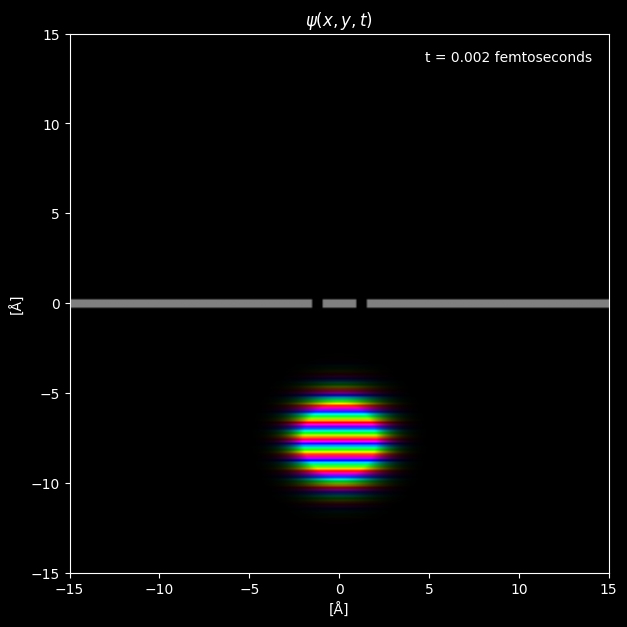

In [ ]:
#2D double slit
import numpy as np
from qmsolve import Hamiltonian, SingleParticle, TimeSimulation, init_visualization, femtoseconds, m_e, Å

#=========================================================================================================#
#First, we define the Hamiltonian of a single particle
#=========================================================================================================#

#interaction potential
def double_slit(particle):
    b = 2.0* Å # slits separation
    a = 0.5* Å # slits width
    d = 0.5* Å # slits depth

    return np.where( ((particle.x < - b/2 - a) | (particle.x > b/2 + a) | ((particle.x > -b/2)
                     & (particle.x < b/2))) & ((particle.y < d/2) & (particle.y > -d/2) ),  1e5,  0)


#build the Hamiltonian of the system
H = Hamiltonian(particles = SingleParticle(m = m_e),
                potential = double_slit,
                spatial_ndim = 2, N = 256, extent = 30 * Å)



#=========================================================================================================#
# Define the wavefunction at t = 0  (initial condition)
#=========================================================================================================#

def initial_wavefunction(particle):
    #This wavefunction correspond to a gaussian wavepacket with a mean Y momentum equal to p_y0
    σ = 1.0 * Å
    v0 = 80 * Å / femtoseconds
    p_y0 = m_e * v0
    return np.exp( -1/(4* σ**2) * ((particle.x-0)**2+(particle.y+8* Å)**2)) / np.sqrt(2*np.pi* σ**2)  *np.exp(p_y0*particle.y*1j)


#=========================================================================================================#
# Set and run the simulation
#=========================================================================================================#


total_time = 0.7 * femtoseconds
sim = TimeSimulation(hamiltonian = H, method = "split-step")
sim.run(initial_wavefunction, total_time = total_time, dt = total_time/8000., store_steps = 800)


#=========================================================================================================#
# Finally, we visualize the time dependent simulation
#=========================================================================================================#

visualization = init_visualization(sim)

visualization.animate(xlim=[-15* Å,15* Å], ylim=[-15* Å,15* Å], potential_saturation = 0.5, wavefunction_saturation = 0.2, animation_duration = 10, fps = 30)

oscillation_amplitude  5.092958178940651  amstrongs


Took 5.31177830696106


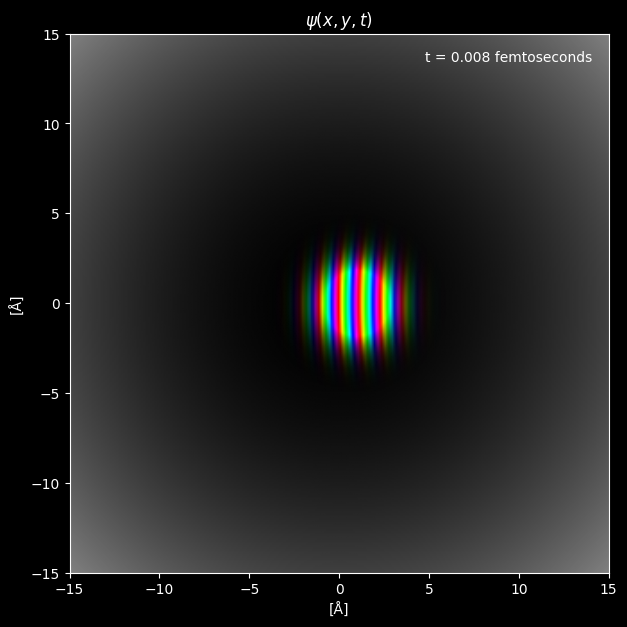

In [ ]:
#2D Harmonic Osscillator
import numpy as np
from qmsolve import Hamiltonian, SingleParticle, TimeSimulation, init_visualization, femtoseconds, m_e, Å

#=========================================================================================================#
#First, we define the Hamiltonian of a single particle confined in an harmonic oscillator potential.
#=========================================================================================================#

#interaction potential
def harmonic_oscillator(particle):
    m = m_e
    T = 0.5*femtoseconds
    w = 2*np.pi/T
    k = m* w**2

    v0 = 64. * Å / femtoseconds
    print("oscillation_amplitude ", np.sqrt(m/k) *v0/Å, " amstrongs")

    return 0.5 * k * particle.x**2    +    0.5 * k * particle.y**2


#build the Hamiltonian of the system
H = Hamiltonian(particles = SingleParticle(m = m_e),
                potential = harmonic_oscillator,
                spatial_ndim = 2, N = 300, extent = 30 * Å)



#=========================================================================================================#
# Define the wavefunction at t = 0  (initial condition)
#=========================================================================================================#

def initial_wavefunction(particle):
    #This wavefunction correspond to a gaussian wavepacket with a mean X momentum equal to p_x0
    σ = 1.0 * Å
    v0 = 64. * Å / femtoseconds
    p_x0 = m_e * v0
    return np.exp( -1/(4* σ**2) * ((particle.x-0)**2+(particle.y-0)**2)) / np.sqrt(2*np.pi* σ**2)  *np.exp(p_x0*particle.x*1j)


#=========================================================================================================#
# Set and run the simulation
#=========================================================================================================#


total_time = 1.5 * femtoseconds
sim = TimeSimulation(hamiltonian = H, method = "split-step")
sim.run(initial_wavefunction, total_time = total_time, dt = total_time/1000., store_steps = 400)


#=========================================================================================================#
# Finally, we visualize the time dependent simulation
#=========================================================================================================#

visualization = init_visualization(sim)
visualization.animate(xlim=[-15* Å,15* Å], ylim=[-15* Å,15* Å], potential_saturation = 0.5, wavefunction_saturation = 0.2, animation_duration = 10, save_animation = False)


#for visualizing a single frame, use plot method instead of animate:
#visualization.plot(t = 5/4 * 1 * femtoseconds,xlim=[-15* Å,15* Å], ylim=[-15* Å,15* Å], potential_saturation = 0.5, wavefunction_saturation = 0.2)

Took 11.449350357055664


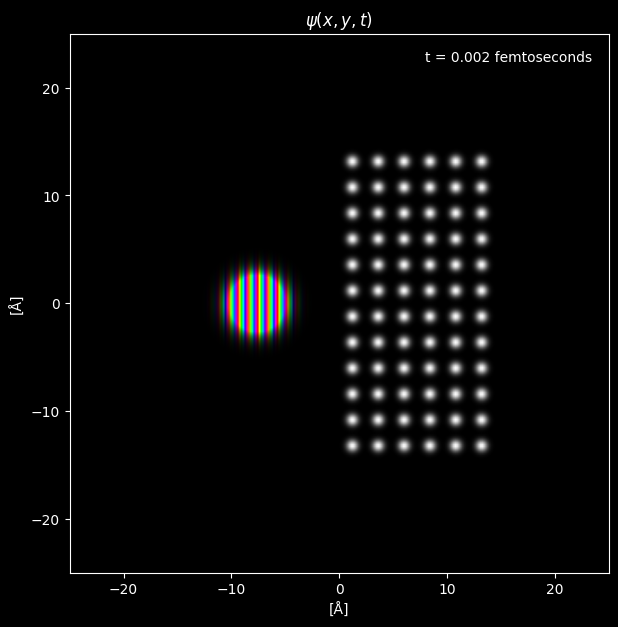

In [ ]:
#2D Lattice Scattering
import numpy as np
from qmsolve import Hamiltonian, SingleParticle, TimeSimulation, init_visualization, femtoseconds, m_e, Å


def lattice_point(x,y, x0,y0):
    σ = 0.5
    V0 = 40
    return V0*np.exp( -1/(4* σ**2) * ((x-x0)**2+(y-y0)**2))

Nx_point = 12
Ny_point = 12

x_point, y_point = np.meshgrid(np.linspace(-50/2, 50/2, Nx_point),
                               np.linspace(-50/2, 50/2, Ny_point))

#interaction potential
def lattice(particle):
    V = 0
    for i in range(0,Nx_point):
        for j in range(Ny_point//2,Ny_point):
            V += lattice_point(particle.x,particle.y, x_point[i,j],y_point[i,j])
    return V


#build the Hamiltonian of the system
H = Hamiltonian(particles = SingleParticle(m = m_e),
                potential = lattice,
                spatial_ndim = 2, N = 300, extent = 50 * Å)


# Define the wavefunction at t = 0  (initial condition)
def initial_wavefunction(particle):
    #This wavefunction correspond to a gaussian wavepacket with a mean X momentum equal to p_x0
    σ = 1.0 * Å
    v0 = 80 * Å / femtoseconds
    p_x0 = m_e * v0
    return np.exp( -1/(4* σ**2) * ((particle.x+15)**2+(particle.y-0)**2)) / np.sqrt(2*np.pi* σ**2)  *np.exp(p_x0*particle.x*1j)



# Set and run the simulation
total_time = 0.4 * femtoseconds
sim = TimeSimulation(hamiltonian = H, method = "split-step")
sim.run(initial_wavefunction, total_time = total_time, dt = total_time/2000., store_steps = 500)


# Finally, we visualize the time dependent simulation
visualization = init_visualization(sim)
visualization.animate(xlim=[-25* Å,25* Å], ylim=[-25* Å,25* Å], potential_saturation = 1.0, wavefunction_saturation = 0.1, animation_duration = 10, fps = 20)

Took 28.725621700286865


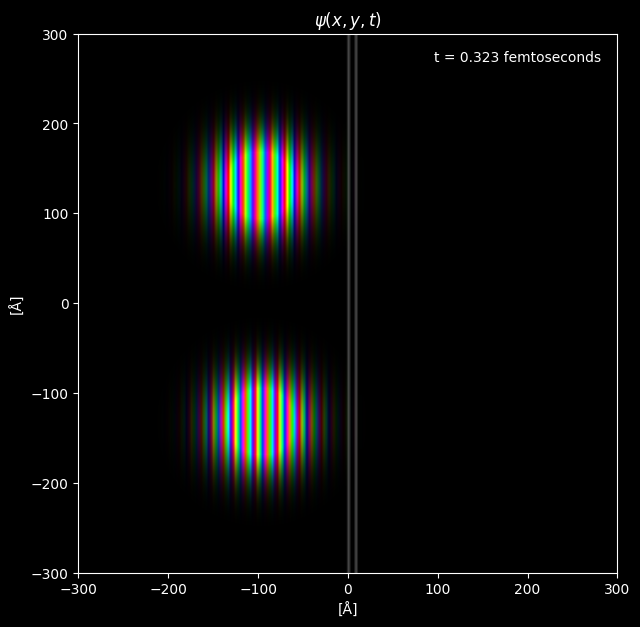

In [ ]:
#2D Quantum Resonant Tunneling
import numpy as np
from qmsolve import Hamiltonian, SingleParticle, TimeSimulation, init_visualization, femtoseconds, m_e, Å, eV

#=========================================================================================================#
# First, we define the Hamiltonian of a single particle.
# The interaction potential consists of a double potential barrier
#=========================================================================================================#


def potential(particle):

    #interaction potential
    a = 3*Å
    b = 5*Å
    V0 = 1.7*eV

    #first barrier
    V =  np.where((particle.x>0) & (particle.x<a) , V0, 0.)

    #second barrier
    V =  np.where((particle.x>a+b) & (particle.x<a+b+a)  , V + V0 , V)
    return V


#build the Hamiltonian of the system
H = Hamiltonian(particles = SingleParticle(m = m_e),
                potential = potential,
                spatial_ndim = 2, N = 256, extent = 700*Å)



#=========================================================================================================#
# Define the wavefunction at t = 0  (initial condition)
#=========================================================================================================#

E1 = 0.6*eV
E2 = 1.0*eV

σ = 25.0*Å
p1_x0 = np.sqrt(2*E1 / m_e)
p2_x0 = np.sqrt(2*E2 / m_e)

def initial_wavefunction(particle):
    #This wavefunction correspond to a gaussian wavepacket with a mean X momentum equal to p_x0
    return (np.exp( -1/(4* σ**2) * ((particle.x+100*Å)**2+ 1*(particle.y-250)**2)) / np.sqrt(2*np.pi* σ**2)  *np.exp(p1_x0*particle.x*1j) +
           np.exp( -1/(4* σ**2) * ((particle.x+100*Å)**2+ 1*(particle.y+250)**2)) / np.sqrt(2*np.pi* σ**2)  *np.exp(p2_x0*particle.x*1j))


#=========================================================================================================#
# Set and run the simulation
#=========================================================================================================#


total_time = 4000
sim = TimeSimulation(hamiltonian = H, method = "split-step")
sim.run(initial_wavefunction, total_time = total_time, dt = total_time/8000., store_steps = 800)


#=========================================================================================================#
# Finally, we visualize the time dependent simulation
#=========================================================================================================#

visualization = init_visualization(sim)

visualization.animate(xlim=[-300*Å,300*Å], ylim=[-300*Å,300*Å], potential_saturation = 0.3, wavefunction_saturation = 0.3, animation_duration = 10, fps = 30)